# In this we do some eda analysis to practice python libraries on famous titanic dataset.

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('bmh')

In [2]:
df=pd.read_csv('./Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [7]:
df.shape

(891, 12)

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
# missing values
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
# duplicates
df.duplicated().sum()

np.int64(0)

#### Analysis

Age
* most passengers were about what age?
* is age normally distributed?
* any children?
* any old people?

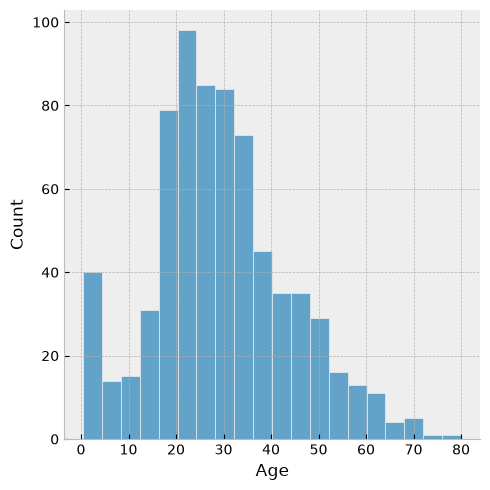

In [14]:
sns.displot(data=df,x='Age',kind='hist')

Gender
* More males?
* More females?

<Axes: xlabel='Sex', ylabel='count'>

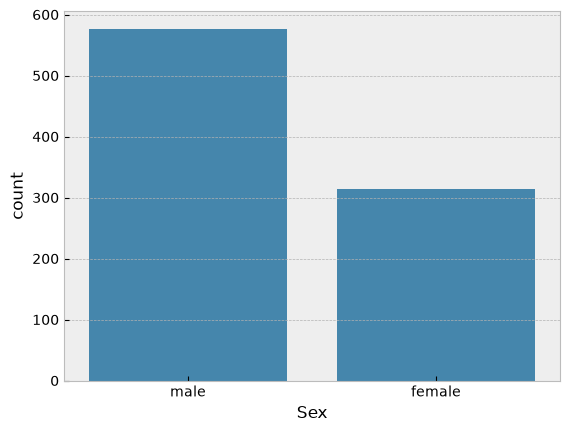

In [18]:
sns.countplot(data=df,x='Sex')

Passenger Class
* Which class had the most passenger

<Axes: xlabel='Pclass', ylabel='count'>

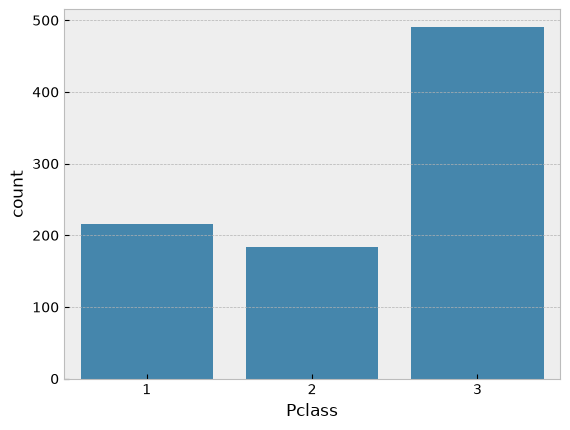

In [19]:
sns.countplot(data=df,x='Pclass')

#### Bivariate Analysis

Survived vs Gender: kitne genders se kitne survive kiya hai

<Axes: xlabel='Survived', ylabel='count'>

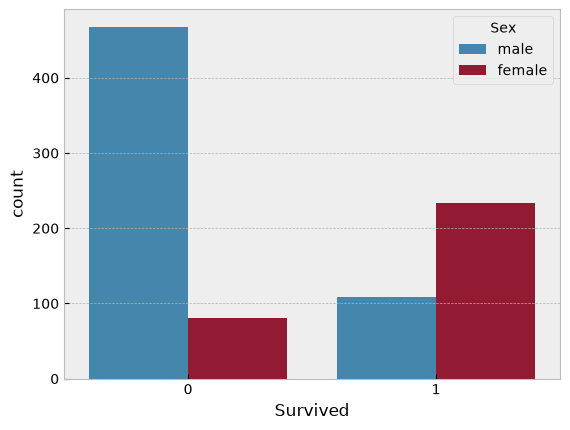

In [20]:
sns.countplot(data=df,x='Survived',hue='Sex')

it tells us 0th class males survided more than females and in 1st class females survided more than males

Age vs Survival

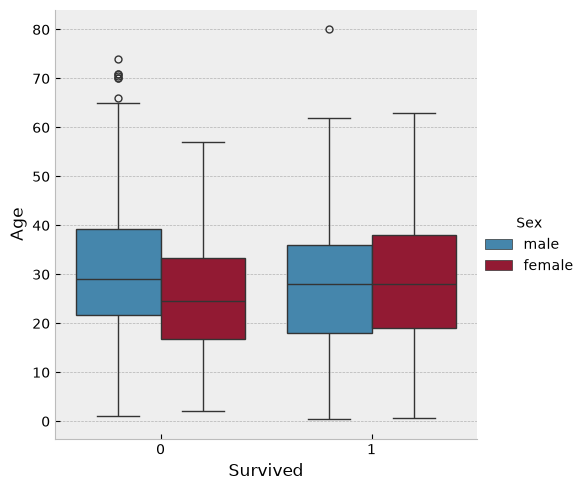

In [21]:
sns.catplot(kind='box',data=df,x='Survived',y='Age',hue='Sex')

it tells us how many men and women from different age groups survivded

Fare vs Survival
does rich passengers survived more?

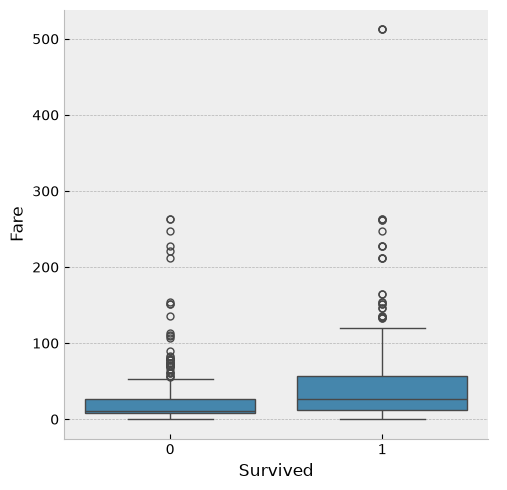

In [22]:
sns.catplot(kind='box',data=df,x='Survived',y='Fare')

it tells that 1st-> females survived more

1. Now , survived passengers are of which gender and which class

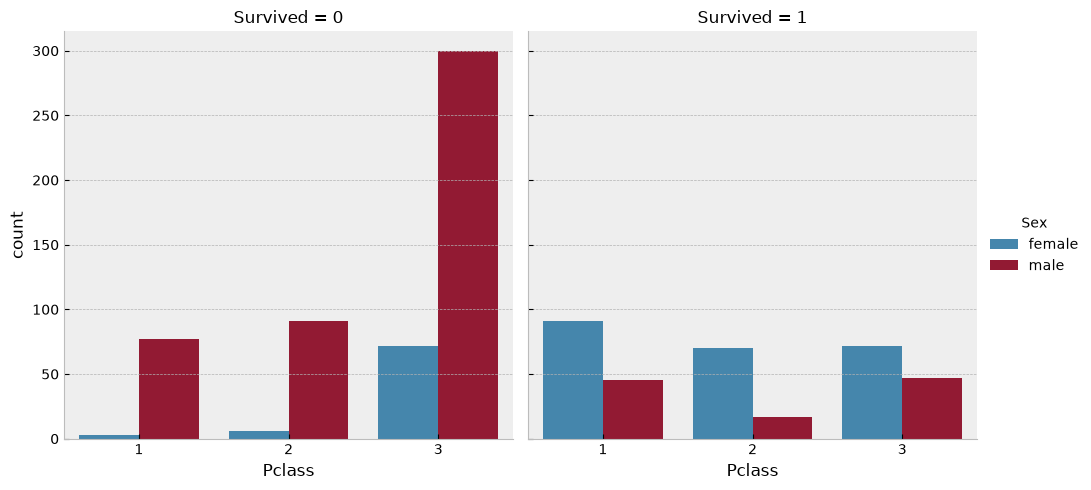

In [23]:
sns.catplot(kind='count',data=df,x='Pclass',hue='Sex',col='Survived') #what col does? it simply gives the seperate values

Correlation

<Axes: >

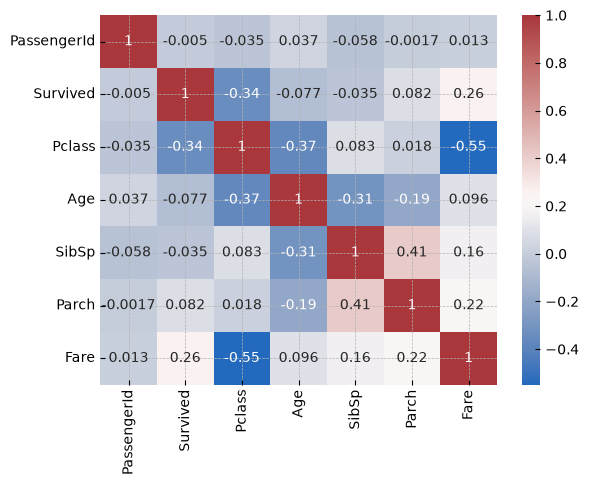

In [ ]:
# heatmap only applied to numeric values so we need to take only numeric values from the df
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='vlag')
# vlag is used to show the data with different colors

which variables are related?

#### GroupBy

In [30]:
# avg of males vs females on age
df.groupby("Sex")['Age'].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

the above mean shows that female are mostly of 28 age and males are of 31 age

In [31]:
# avg fare by class
df.groupby("Pclass")['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [ ]:
# avg age of survivors
df.groupby("Survived")['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [53]:
df=pd.read_csv('./Titanic-Dataset.csv')

In [3]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [4]:
df['Age'].isnull().sum()

np.int64(0)

In [5]:
type(df)

pandas.DataFrame

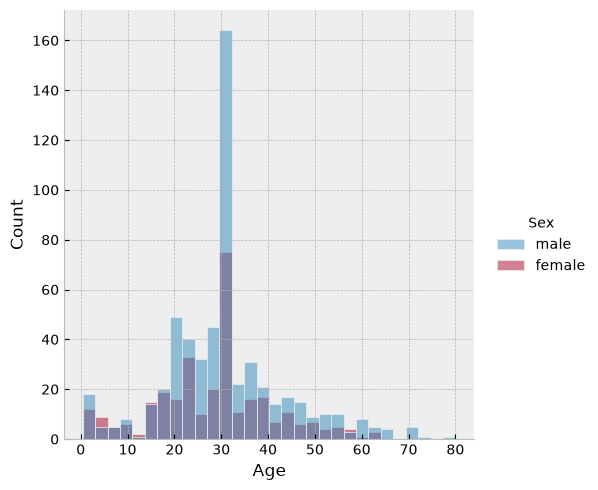

In [57]:
# apply univariate to df , after filling missing values with avg
sns.displot(data=df,x='Age',hue='Sex',kind='hist')

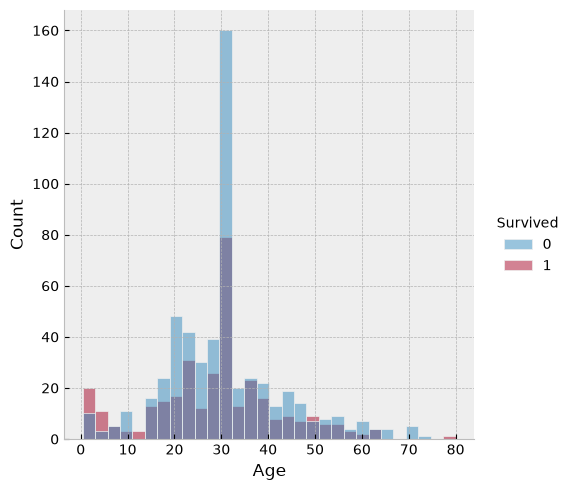

In [58]:
sns.displot(data=df,x='Age',hue='Survived',kind='hist')

In [60]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [61]:
df['Cabin']

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: str

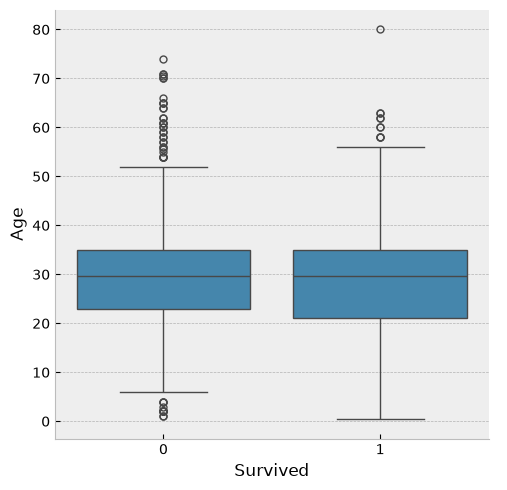

In [ ]:
# bivariate analysis
# Survived vs Age
sns.catplot(data=df,x='Survived',y='Age',kind='box')

<Axes: >

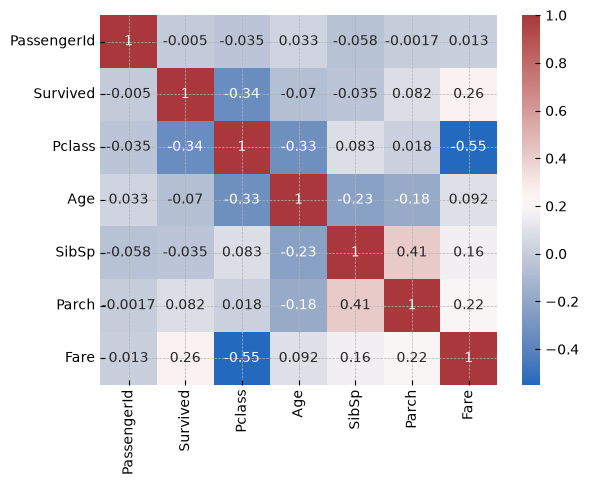

In [8]:
# heatmap
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='vlag')

removing outliers

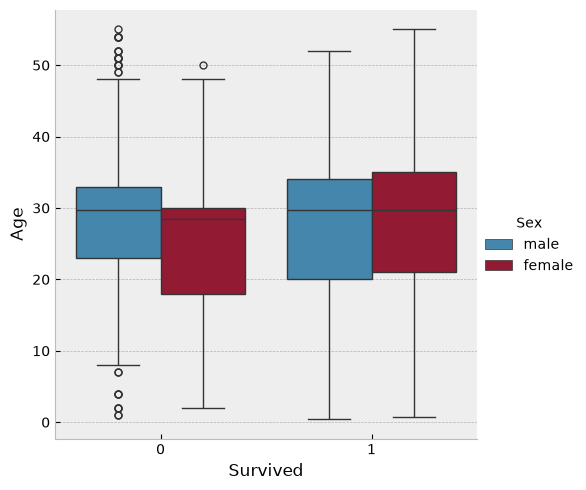

In [16]:
removed_outliers=df[df['Age']<=55]
sns.catplot(data=removed_outliers,x='Survived',y='Age',hue='Sex',kind='box')

### We solve some questions here

1. How many passengers survived

In [18]:
df['Survived'].sum()

np.int64(342)

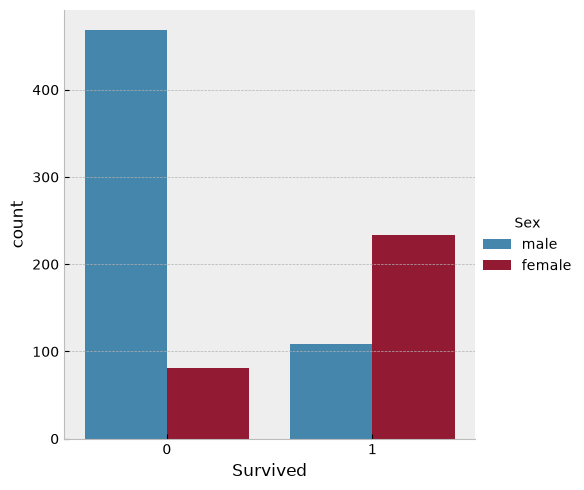

In [ ]:
# above data says, 342 survives, we visulize it
sns.catplot(data=df,kind='count',x='Survived',hue='Sex')

2. Male vs Female numbers of survivals

In [6]:
df=pd.read_csv('./Titanic-Dataset.csv')
df.groupby('Survived')['Sex'].value_counts()

Survived  Sex   
0         male      468
          female     81
1         female    233
          male      109
Name: count, dtype: int64

now this shows 233 females and 109 males survived

3. Male vs Female survival rate?

In [15]:
df.groupby('Sex')['Sex'].value_counts()

Sex
female    314
male      577
Name: count, dtype: int64

In [16]:
# so , from above , total females=314, total males=577
# that means , percentage of survial
males = (109/577)*100
females = (233/314)*100
print(f"Male survival percentage is:{males}% and female survival percentage is:{females}%")

Male survival percentage is:18.890814558058924% and female survival percentage is:74.20382165605095%


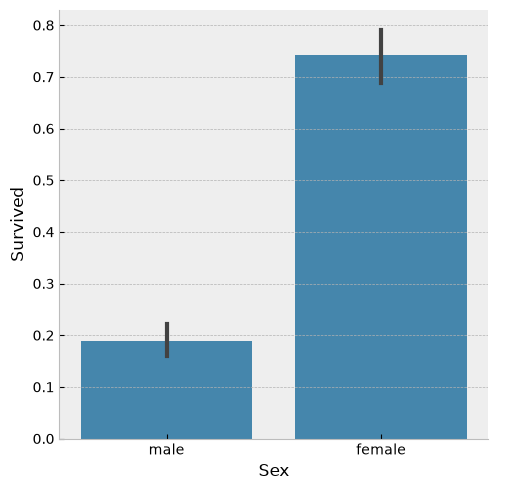

In [20]:
sns.catplot(data=df,kind='bar',x='Sex',y='Survived')

4. Which class survived the most?

In [17]:
df.groupby('Pclass')['Pclass'].value_counts()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [18]:
df.groupby('Survived')['Pclass'].value_counts()

Survived  Pclass
0         3         372
          2          97
          1          80
1         1         136
          3         119
          2          87
Name: count, dtype: int64

In [19]:
# we have to take 1-> wala dataset as, 0-> presents not survived, 1-> represents survived
first=(136/216)*100
second=(87/184)*100
third=(119/491)*100
print(f"first class={first}%\nsecond class={second}%\nthird class={third}%")

first class=62.96296296296296%
second class=47.28260869565217%
third class=24.236252545824847%


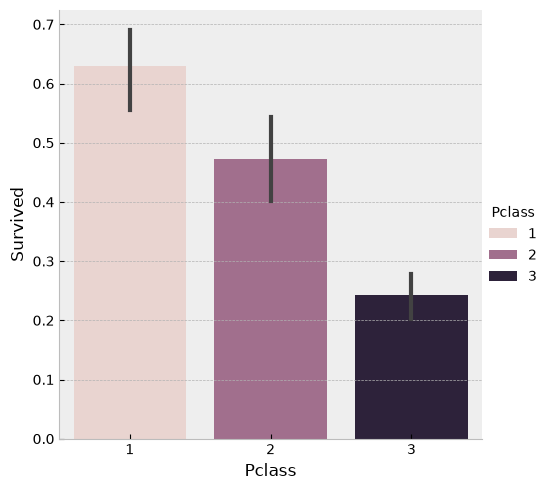

In [21]:
sns.catplot(data=df,kind='bar',x='Pclass',y='Survived',hue='Pclass')

5. Average fare per class?

In [25]:
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

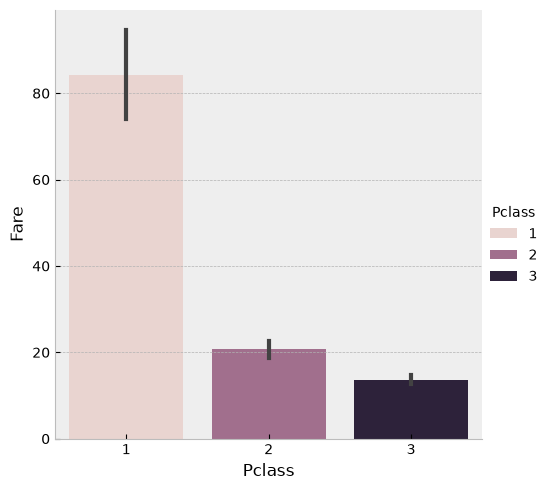

In [26]:
sns.catplot(data=df,kind='bar',x='Pclass',y='Fare',hue='Pclass')

6. Average age per class

In [27]:
df.groupby('Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

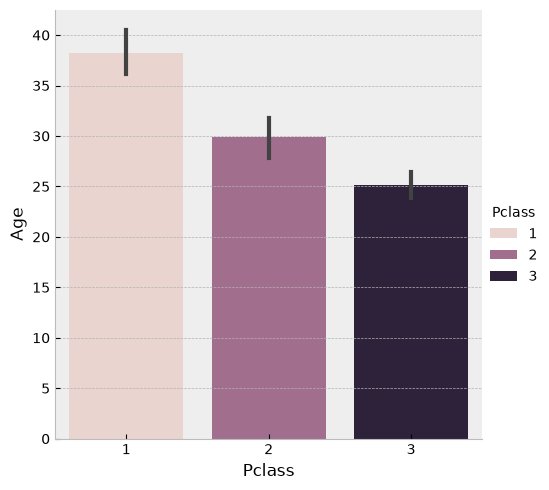

In [28]:
sns.catplot(data=df,kind='bar',x='Pclass',y='Age',hue='Pclass')

7. Which embarkation point had the highest survival?

In [29]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
df.groupby('Survived')['Embarked'].max()

Survived
0    S
1    S
Name: Embarked, dtype: str

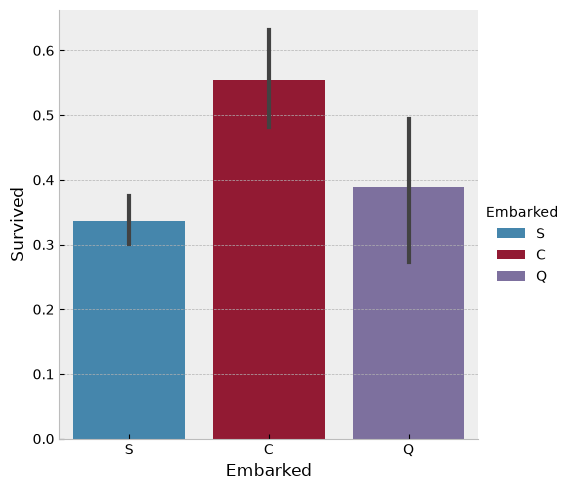

In [32]:
sns.catplot(data=df,kind='bar',x='Embarked',y='Survived',hue='Embarked')

8. Did children survive more?

In [ ]:
age=df[df['Age'] <= 18]
age.groupby('Survived')['Age'].count()

Survived
0    69
1    70
Name: Age, dtype: int64

from above information we see, out of 139 children, 70 children survived

9. Did rich passengers survive more?

In [55]:
# rich kon? jinhone fair jyada diya hoga? mostly first class people
df.groupby('Fare')['Survived'].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

11. Who paid the highest fare?

In [66]:
fare_name=df['Fare']
fare_name=df.set_index('Name')
fare_name['Fare'].sort_values(ascending=False)

Name
Cardeza, Mr. Thomas Drake Martinez    512.3292
Ward, Miss. Anna                      512.3292
Lesurer, Mr. Gustave J                512.3292
Fortune, Miss. Mabel Helen            263.0000
Fortune, Mr. Mark                     263.0000
                                        ...   
Andrews, Mr. Thomas Jr                  0.0000
Fry, Mr. Richard                        0.0000
Campbell, Mr. William                   0.0000
Frost, Mr. Anthony Wood "Archie"        0.0000
Reuchlin, Jonkheer. John George         0.0000
Name: Fare, Length: 891, dtype: float64

12. Did family size affect survival?

In [3]:
# we need find every passenger family size
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df['FamilySize'] = df['SibSp']+df['Parch']+1
df['Alone'] = 1;
df.loc[df['FamilySize']>1,'Alone'] = 0
# so it creates two columns, familysize and alone
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1


In [11]:
df.groupby('FamilySize')['Survived'].sum()

FamilySize
1     163
2      89
3      59
4      21
5       3
6       3
7       4
8       0
11      0
Name: Survived, dtype: int64

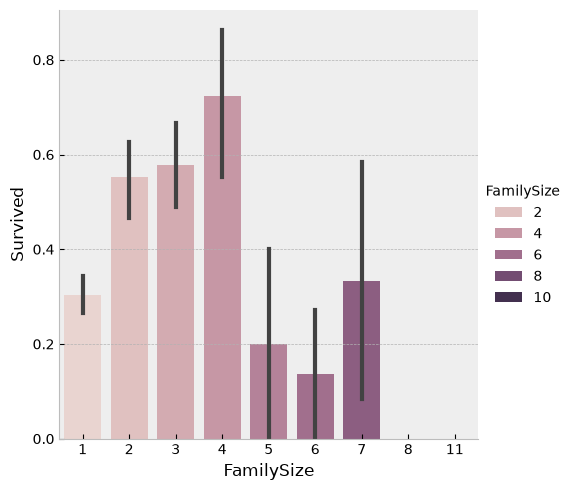

In [31]:
sns.catplot(kind='bar',data=df,x='FamilySize',y='Survived',hue='FamilySize')

the above graph shows the probablity to surviving according to family size

13. WHich age group had the highest survival

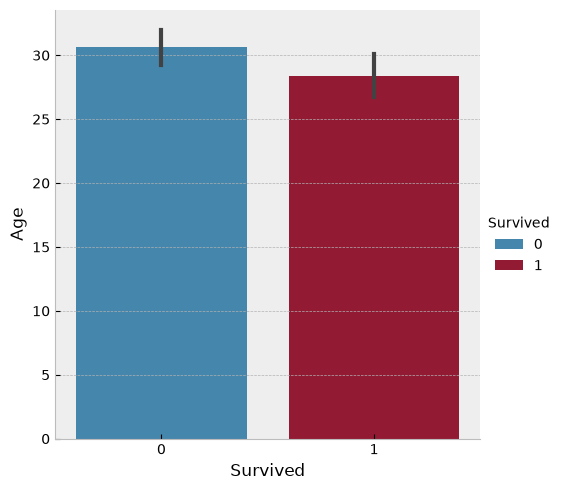

In [30]:
sns.catplot(kind='bar',data=df,x='Survived',y='Age',hue='Survived')

from above bar graph we can see that the age group between 25-30 has highest survival chances (0-> not survived, 1->survived)

14. Which class had the oldest passengers

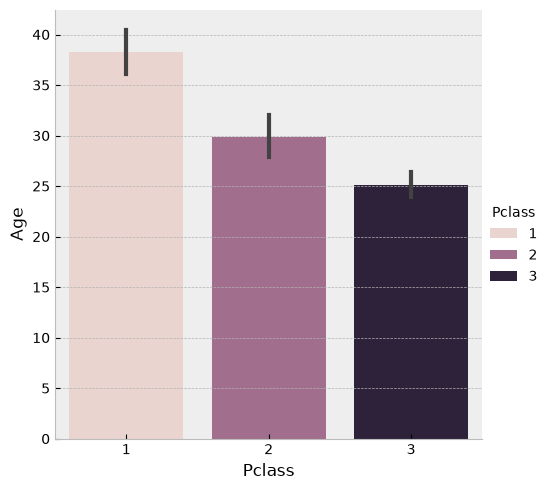

In [ ]:
sns.catplot(kind='bar',data=df,x='Pclass',y='Age',hue='Pclass')

In [39]:
p_cls=df[df['Pclass']==1]
p_cls['Age'].sort_values(ascending=False)

630    80.0
96     71.0
493    71.0
745    70.0
456    65.0
       ... 
766     NaN
793     NaN
815     NaN
839     NaN
849     NaN
Name: Age, Length: 216, dtype: float64

In [42]:
df['Age'].isnull().sum()

np.int64(177)

In [43]:
df['Cabin'].isnull().sum()

np.int64(687)

### Summary from this analysis:
* The dataset contains 891 passengers and 12 features.
* The Age and Cabin columns contained missing values, Age contains 177 missing values and Cabin contains 687 missing values.
* Female passengers had a significantly higher survival rate than male passengers.
* First-class passengers had the highest survival probability, while third-class passengers had the lowest.
* Passengers who paid higher fares generally had a better chance of survival.
* Children tended to have a higher survival rate than adults.
* Most passengers were between 25-35years old.
* Family size appeared to influence survival, with passengers traveling in very large groups had low survival rate meanwhile, alone passengers had high survival rate.
* S(Southampton) was the most common embarkation port
* Passenger class, gender, and fare appear to be among the strongest factors associated with survival.